# About Data:

A fast-food chain plans to add a new item to its menu. However, they are still undecided between three possible marketing campaigns for promoting the new product. In order to determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets. A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks.

# Research:

The goal of this research is to determine which marketing strategy works best in terms of weekly sales. We'll try to answer this question by applying A/B testing methodology in python and testing our hypothesis, which should indicate if there are any significant differences between the promotional strategies.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import io
sns.set()

**Importing and analyzing data**

*Link to dataset*:
https://www.kaggle.com/datasets/chebotinaa/fast-food-marketing-campaign-ab-test/data

In [2]:
data = pd.read_csv('/kaggle/input/fast-food-marketing-campaign-ab-test/WA_Marketing-Campaign.csv')

In [3]:
data.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


There are 548 entries in the dataset, and 548 non-null values, so we don't need to

Let's check if there are any null values

In [5]:
data.isnull().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

It appears there are no missing values in the dataset and our test variable (SalesInThousands) is a numeric datatype. So we should'nt require any further data cleansing.

In [6]:
# number of promotions ran per week
data['week'].value_counts()

week
1    137
2    137
3    137
4    137
Name: count, dtype: int64

Let's check the mean, standard deviation, and sum for sales by promotion.
This will show us initial differences between each type of promotion and indicate the
variability within each group.

In [7]:
data.groupby('Promotion').agg({'SalesInThousands': ['mean', 'std', 'count', 'sum']})

SalesInThousands                           
                      mean        std count       sum
Promotion                                            
1                58.099012  16.553782   172   9993.03
2                47.329415  15.108955   188   8897.93
3                55.364468  16.766231   188  10408.52

Sample sizes seems reasonably large enough to be representative of the population

**Data Visualizations**

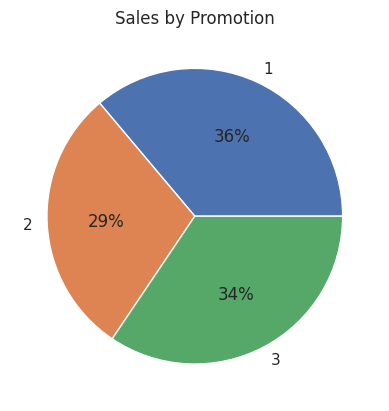

In [8]:
data.groupby('Promotion')['SalesInThousands'].mean().plot(kind='pie', autopct='%1.0f%%')
plt.title('Sales by Promotion')
plt.ylabel('')
plt.show()

It appears the promotion groups contribute roughly one-third of the overall sales.
Let's plot a histogram for overall sales for different promotional strategies

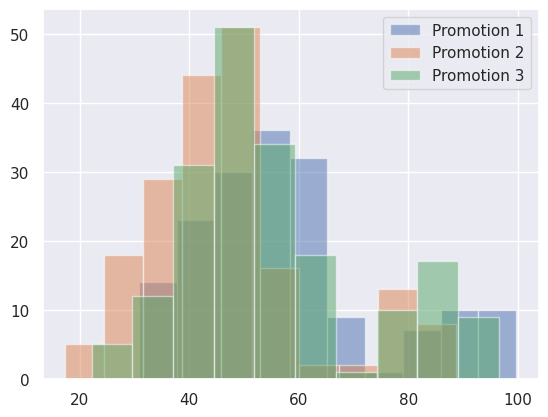

In [9]:
data_promotion1 = data.loc[data['Promotion'] == 1]
data_promotion2 = data.loc[data['Promotion'] == 2]
data_promotion3 = data.loc[data['Promotion'] == 3]

plt.hist(data_promotion1['SalesInThousands'], alpha = 0.5, label='Promotion 1')
plt.hist(data_promotion2['SalesInThousands'], alpha = 0.5, label='Promotion 2')
plt.hist(data_promotion3['SalesInThousands'], alpha = 0.5, label='Promotion 3')
plt.legend(loc='upper right')
plt.show()

array([[<Axes: title={'center': '1'}>, <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: >]], dtype=object)

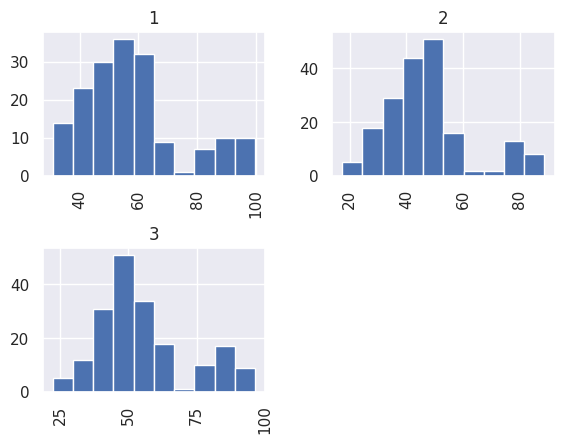

In [10]:
data['SalesInThousands'].hist(by=data['Promotion'])

Data seems somewhat symmetrical but not quite normally distributed.

**Testing for Normality**

We'll use Shapiro Wilk test to test for normality.
Null hypothesis of Shapiro-Wilk test is that a sample comes from a normal distribution.

In [11]:
for promo in data['Promotion'].unique():
    shapiro_wilk_test = stats.shapiro(data.loc[data['Promotion'] == promo]['SalesInThousands'])
    test_statistic = shapiro_wilk_test[0]
    p_value = shapiro_wilk_test[1]
    print(f"promotion {str(promo)}", f"test-statistic: {str(test_statistic)}", f"p-value: {str(p_value)}")

promotion 3 test-statistic: 0.9207683041490243 p-value: 1.49946592611918e-08
promotion 2 test-statistic: 0.914509809064016 p-value: 5.457099666274281e-09
promotion 1 test-statistic: 0.9152999060992891 p-value: 1.97726450444774e-08


Based on the above results, p-value < 0.05. At 95% confidence level we can reject the null hypothesis that the samples come from a normal distribution

**Testing Variance Homogeneity**

We'll use Levene's test to test for Homogeneity of variance.
Null hypothesis of the Levene's test is that the variances of the populations from which the samples are drawn are equal

In [12]:
print(stats.levene(data.loc[data['Promotion'] == 1]['SalesInThousands'],
                   data.loc[data['Promotion'] == 2]['SalesInThousands'],
                   data.loc[data['Promotion'] == 3]['SalesInThousands']))

LeveneResult(statistic=1.2696787527507476, pvalue=0.2817514565692118)


From the Levene test, we can see that the p-value is greater than 0.05;
i.e., we fail to reject the null at 95% confidence level that the variances
of the populations for 3 promotional strategies are likely equal.

From our findings, assumptions of a parametric ANOVA test are not met. We'll apply a Non-Parametric ANOVA test like Kruskal-Wallis test to test our hypothesis.

**Hypotheses**



*   **Null Hypothesis**: All three promotion strategies have the same impact on weekly sales.
*   **Alternative Hypothesis**: At least one promotion strategy leads to significantly different weekly sales compared to the others.



In [13]:
anova_test = stats.kruskal(data.loc[data['Promotion'] == 1]['SalesInThousands'],
              data.loc[data['Promotion'] == 2]['SalesInThousands'],
              data.loc[data['Promotion'] == 3]['SalesInThousands'])

print("p-value:", str(anova_test[1]))

p-value: 2.6741866266697816e-12


Since the p-value is much smaller than 0.05, at 95% confidence level we can reject the Null Hypothesis that All three promotion strategies have the same impact on weekly sales.

Since the ANOVA test indicates significant differences between the means of three promotional groups. We want to see which groups differ. To analyze that, we'll run a post-hoc test, such as **Tukey HSD**.

In [14]:
tukey = pairwise_tukeyhsd(endog=data['SalesInThousands'],
                        groups=data['Promotion'],
                        alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
1,2,-10.7696,0.0,-14.7738,-6.7654,True
1,3,-2.7345,0.2444,-6.7388,1.2697,False
2,3,8.0351,0.0,4.1208,11.9493,True


From the summary table output of the Tukey-HSD test. we can see that the p-values for the pairs '1 & 2' and '2 & 3' is less than 0.05. However, p-value for the pair '1 & 3' is greater than 0.05. As a result, at 95% confidence level, we can say that promotion 2 has a different effect on sales as compared to promotion 1 and promotion 3

Let's use a boxplot to see if we can visualize the proposed difference

<Axes: title={'center': 'SalesInThousands'}, xlabel='Promotion'>

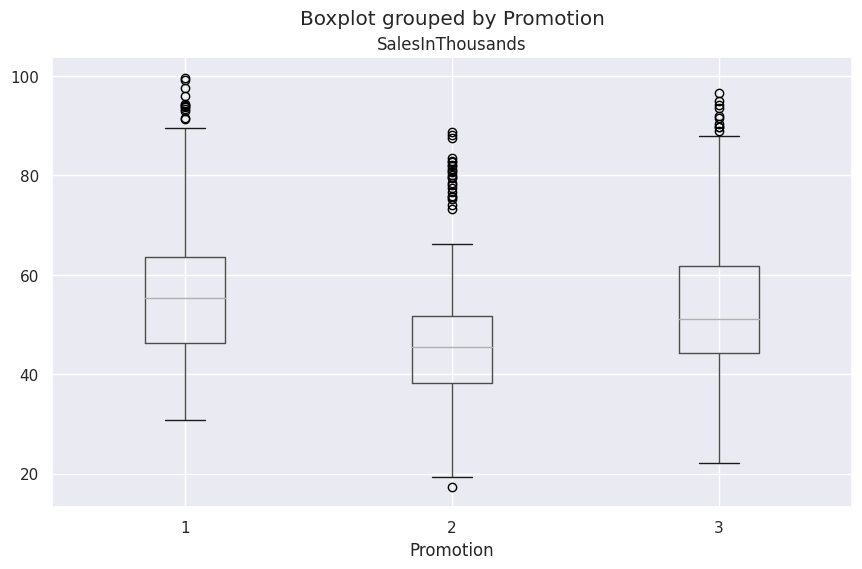

In [15]:
data.boxplot('SalesInThousands', by='Promotion', figsize=(10,6))

Now, we'll try to analyze if any of the following confounding variables have an effect on the Sales:



*   MarketSize
*   AgeOfStore

*   week





**Market Size**

In [16]:
market_stats = stats.f_oneway(data.loc[data['MarketSize'] == 'Small']['SalesInThousands'],
               data.loc[data['MarketSize'] == 'Medium']['SalesInThousands'],
               data.loc[data['MarketSize'] == 'Large']['SalesInThousands'])

print("p-value:", market_stats[1])

p-value: 5.633818717740179e-82


The ANOVA test shows there is statistically significant difference in sales across different market sizes.
Let's visualize Box Plot by Market Sizes

<Axes: xlabel='MarketSize', ylabel='SalesInThousands'>

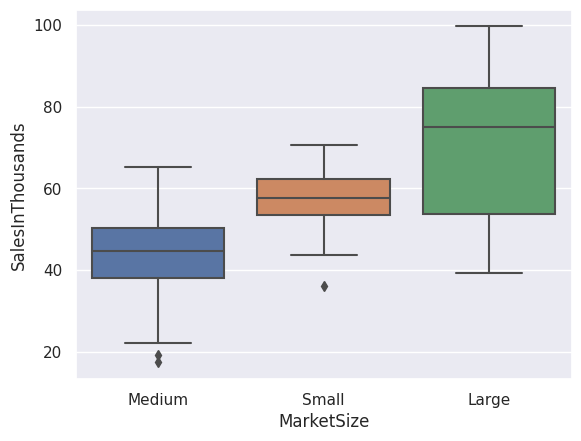

In [17]:
sns.boxplot(x='MarketSize', y='SalesInThousands', data=data)

Large markets consistently show higher sales compared to Medium and Small markets
This shows that the market size is a significant factor affecting sales

**Store Age**

In [18]:
age_correlation = stats.pearsonr(data['AgeOfStore'], data['SalesInThousands'])
print("Corr:", age_correlation[0],"; " "p-value:", age_correlation[1])

Corr: -0.028532881102495668 ; p-value: 0.5050607939715022


The Pearson correlation analysis shows a weak negative correlation between store age and sales.
Let's visualize this relationship with a scatterplot

<Axes: xlabel='AgeOfStore', ylabel='SalesInThousands'>

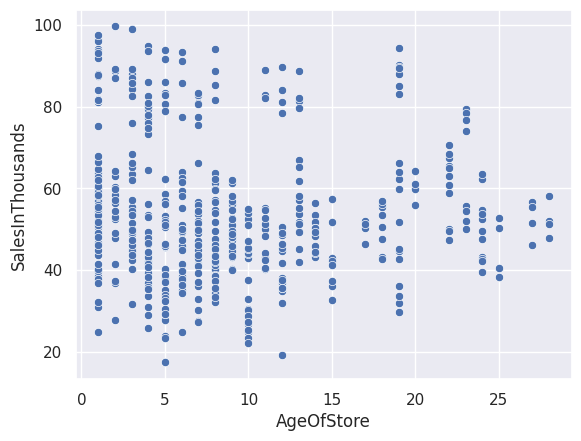

In [19]:
sns.scatterplot(x='AgeOfStore', y='SalesInThousands', data=data)

The relationship is not strong enough to conclude that store age is a major determinant of sales

**Week**

In [20]:
week_stats = stats.f_oneway(data.loc[data['week'] == 1]['SalesInThousands'],
                            data.loc[data['week'] == 2]['SalesInThousands'],
                            data.loc[data['week'] == 3]['SalesInThousands'],
                            data.loc[data['week'] == 4]['SalesInThousands'])

print("p_value:", week_stats[1])

p_value: 0.9935340991532374


The ANOVA test for weeks shows no statistically significant difference in sales across weeks (p > 0.05),
This suggests that sales remain relatively stable across the four weeks. Let's vizualize this with a boxplot

<Axes: xlabel='week', ylabel='SalesInThousands'>

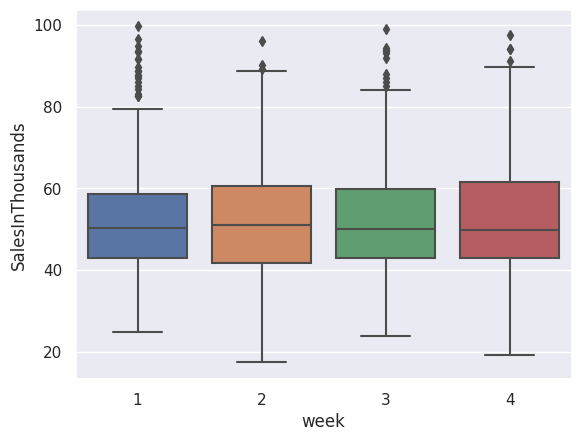

In [21]:
sns.boxplot(x='week', y='SalesInThousands', data=data)

**Key Conclusions**:

*   Promotion Strategies 1 & 3 outperform promotion Strategy 2. The difference in mean sales between Promotion 1 and 3 is not significant.
*   Market Size is a strong predictor of sales performance. Large markets are shown to be outperforming Small and Medium Markets.

*   Store age has a minor to no effect on sales.
*   Weekly variations are not significant.





**Summary (Business Recommendations):**

In my analysis, I found that the company should either use Promotion 1 or Promotion 3 to maximize their sales. Store Age has minor to no effect on sales, so in future new stores in bigger Market Sizes may also be beneficial, however, further research may be required with market specific data to draw strong conclusions about bigger Market Size.